In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import shap

# 1. Loading the Dataset

## 1.1 Loading a Dataset from scikit-learn

In [2]:
## Cancer classification
cancer_data = load_breast_cancer()

## 1.2 Creating the DataFrame

In [3]:
## Separate X (features) and y (target) variables
## Convert them into pandas DataFrame format
X = pd.DataFrame(cancer_data["data"], columns=cancer_data["feature_names"])
y = pd.Series(cancer_data["target"])

In [4]:
## Display the first 5 rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
## Display the first 5 rows
y.head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

# 2. Dataset Quality Checks

## 2.1 Missing Value Analysis

In [6]:
## Check each column for missing values
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [7]:
## If there are missing values, apply an appropriate imputation method (mean/median)

## There are no missing values in the dataset

## 2.2 Outlier Analysis

In [8]:
## Use at least one of the following methods:
## IQR method
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X < Q1 - 1.5 * IQR) | (X > Q3 + 1.5 * IQR))
outliers = X[outlier_mask.any(axis=1)]

print("Number of rows with outliers:", outliers.shape[0])
outliers.head()

Number of rows with outliers: 171


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2.3 Data Type and Distribution Review

In [9]:
## Report the number of numerical and categorical variables.
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

print("Number of numerical variables:", len(num_cols))
print("Number of categorical variables:", len(cat_cols))

Number of numerical variables: 30
Number of categorical variables: 0


In [10]:
## Show the dtype information for each column
print(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

# 3. Exploratory Data Analysis (EDA)

## 3.1 Statistical Properties

In [11]:
## The mean, Min-Max, Std, Q1, Q3 of each feature
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
## The median of each feature
for i in range(X.shape[1]):
    print(f"The median of {X.columns[i]}: {np.median(X.iloc[:, i]):.2f}")

The median of mean radius: 13.37
The median of mean texture: 18.84
The median of mean perimeter: 86.24
The median of mean area: 551.10
The median of mean smoothness: 0.10
The median of mean compactness: 0.09
The median of mean concavity: 0.06
The median of mean concave points: 0.03
The median of mean symmetry: 0.18
The median of mean fractal dimension: 0.06
The median of radius error: 0.32
The median of texture error: 1.11
The median of perimeter error: 2.29
The median of area error: 24.53
The median of smoothness error: 0.01
The median of compactness error: 0.02
The median of concavity error: 0.03
The median of concave points error: 0.01
The median of symmetry error: 0.02
The median of fractal dimension error: 0.00
The median of worst radius: 14.97
The median of worst texture: 25.41
The median of worst perimeter: 97.66
The median of worst area: 686.50
The median of worst smoothness: 0.13
The median of worst compactness: 0.21
The median of worst concavity: 0.23
The median of worst conc

## 3.2 Correlation Matrix

In [13]:
## Create the Pearson correlation matrix
corr_matrix = X.corr(method="pearson")
corr_matrix

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


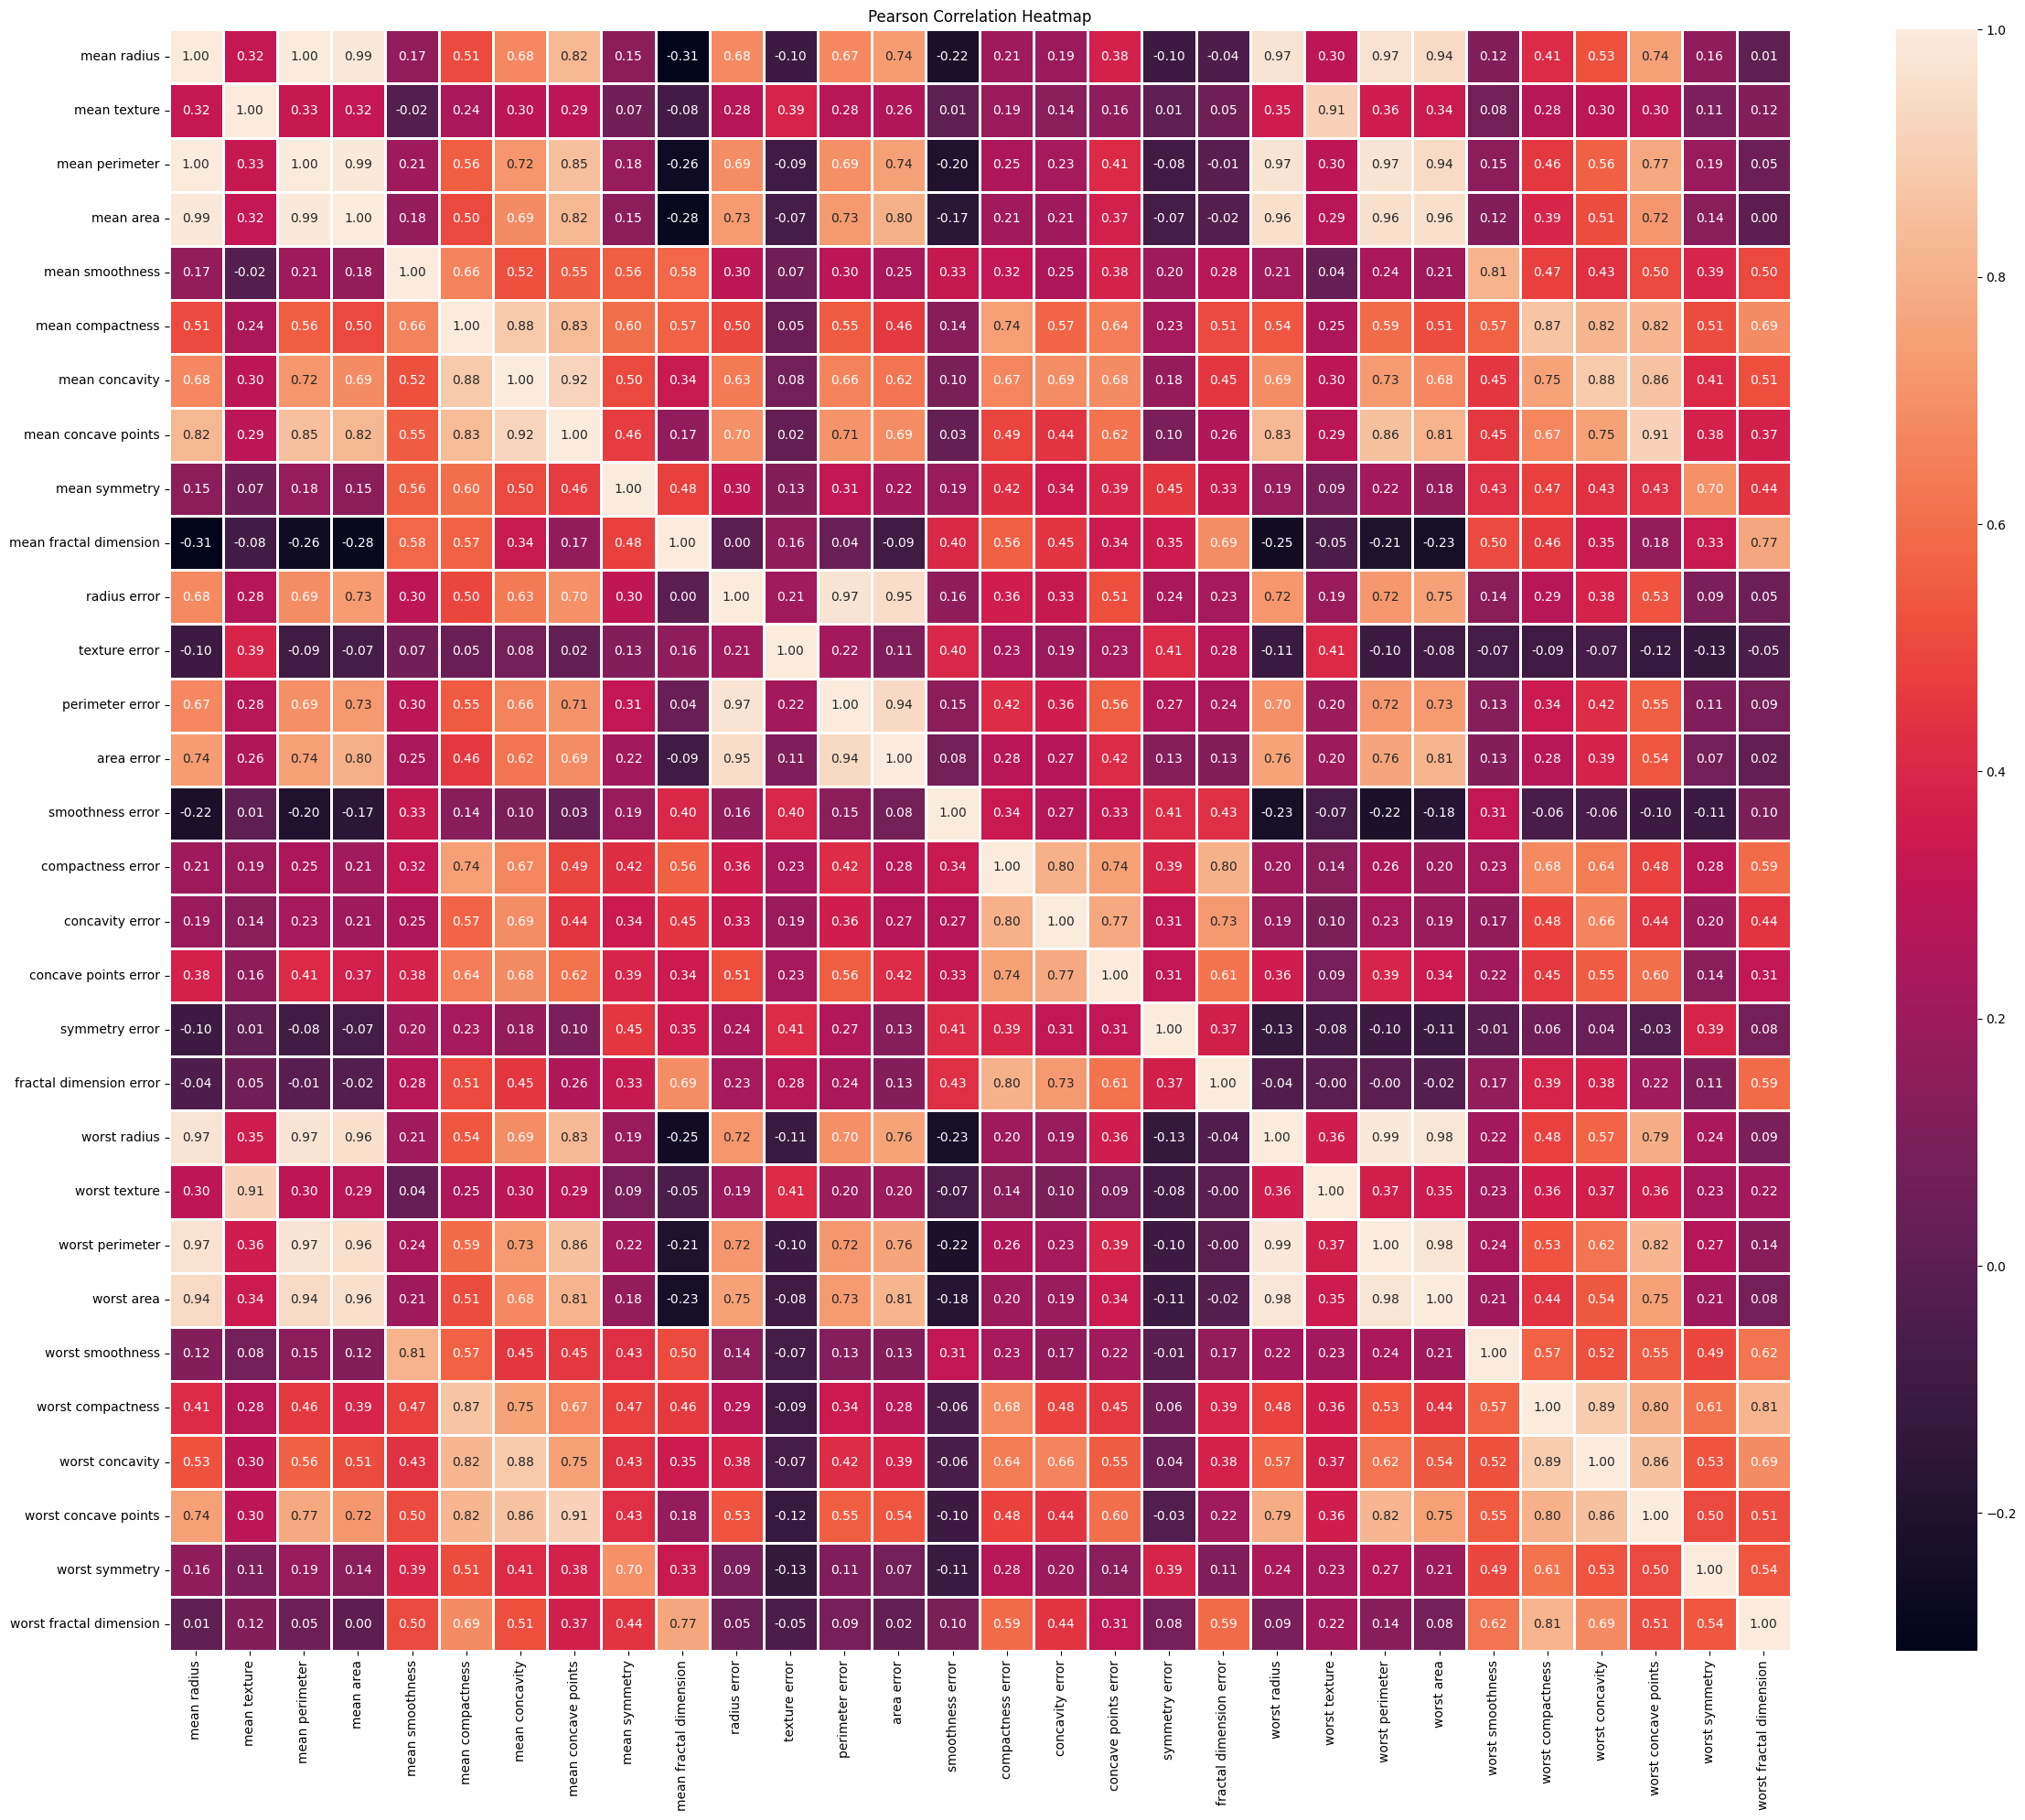

In [14]:
## Visualize it with a heatmap
plt.figure(figsize=(25, 20))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=1, square=True)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

In [15]:
## The top 3 most highly correlated feature pairs.

"""
mean perimeter - mean radius : 1
mean radius - mean perimeter : 0.99
mean area - mean radius : 0.99
"""

'\nmean perimeter - mean radius : 1\nmean radius - mean perimeter : 0.99\nmean area - mean radius : 0.99\n'

## 3.3 Boxplot Analysis

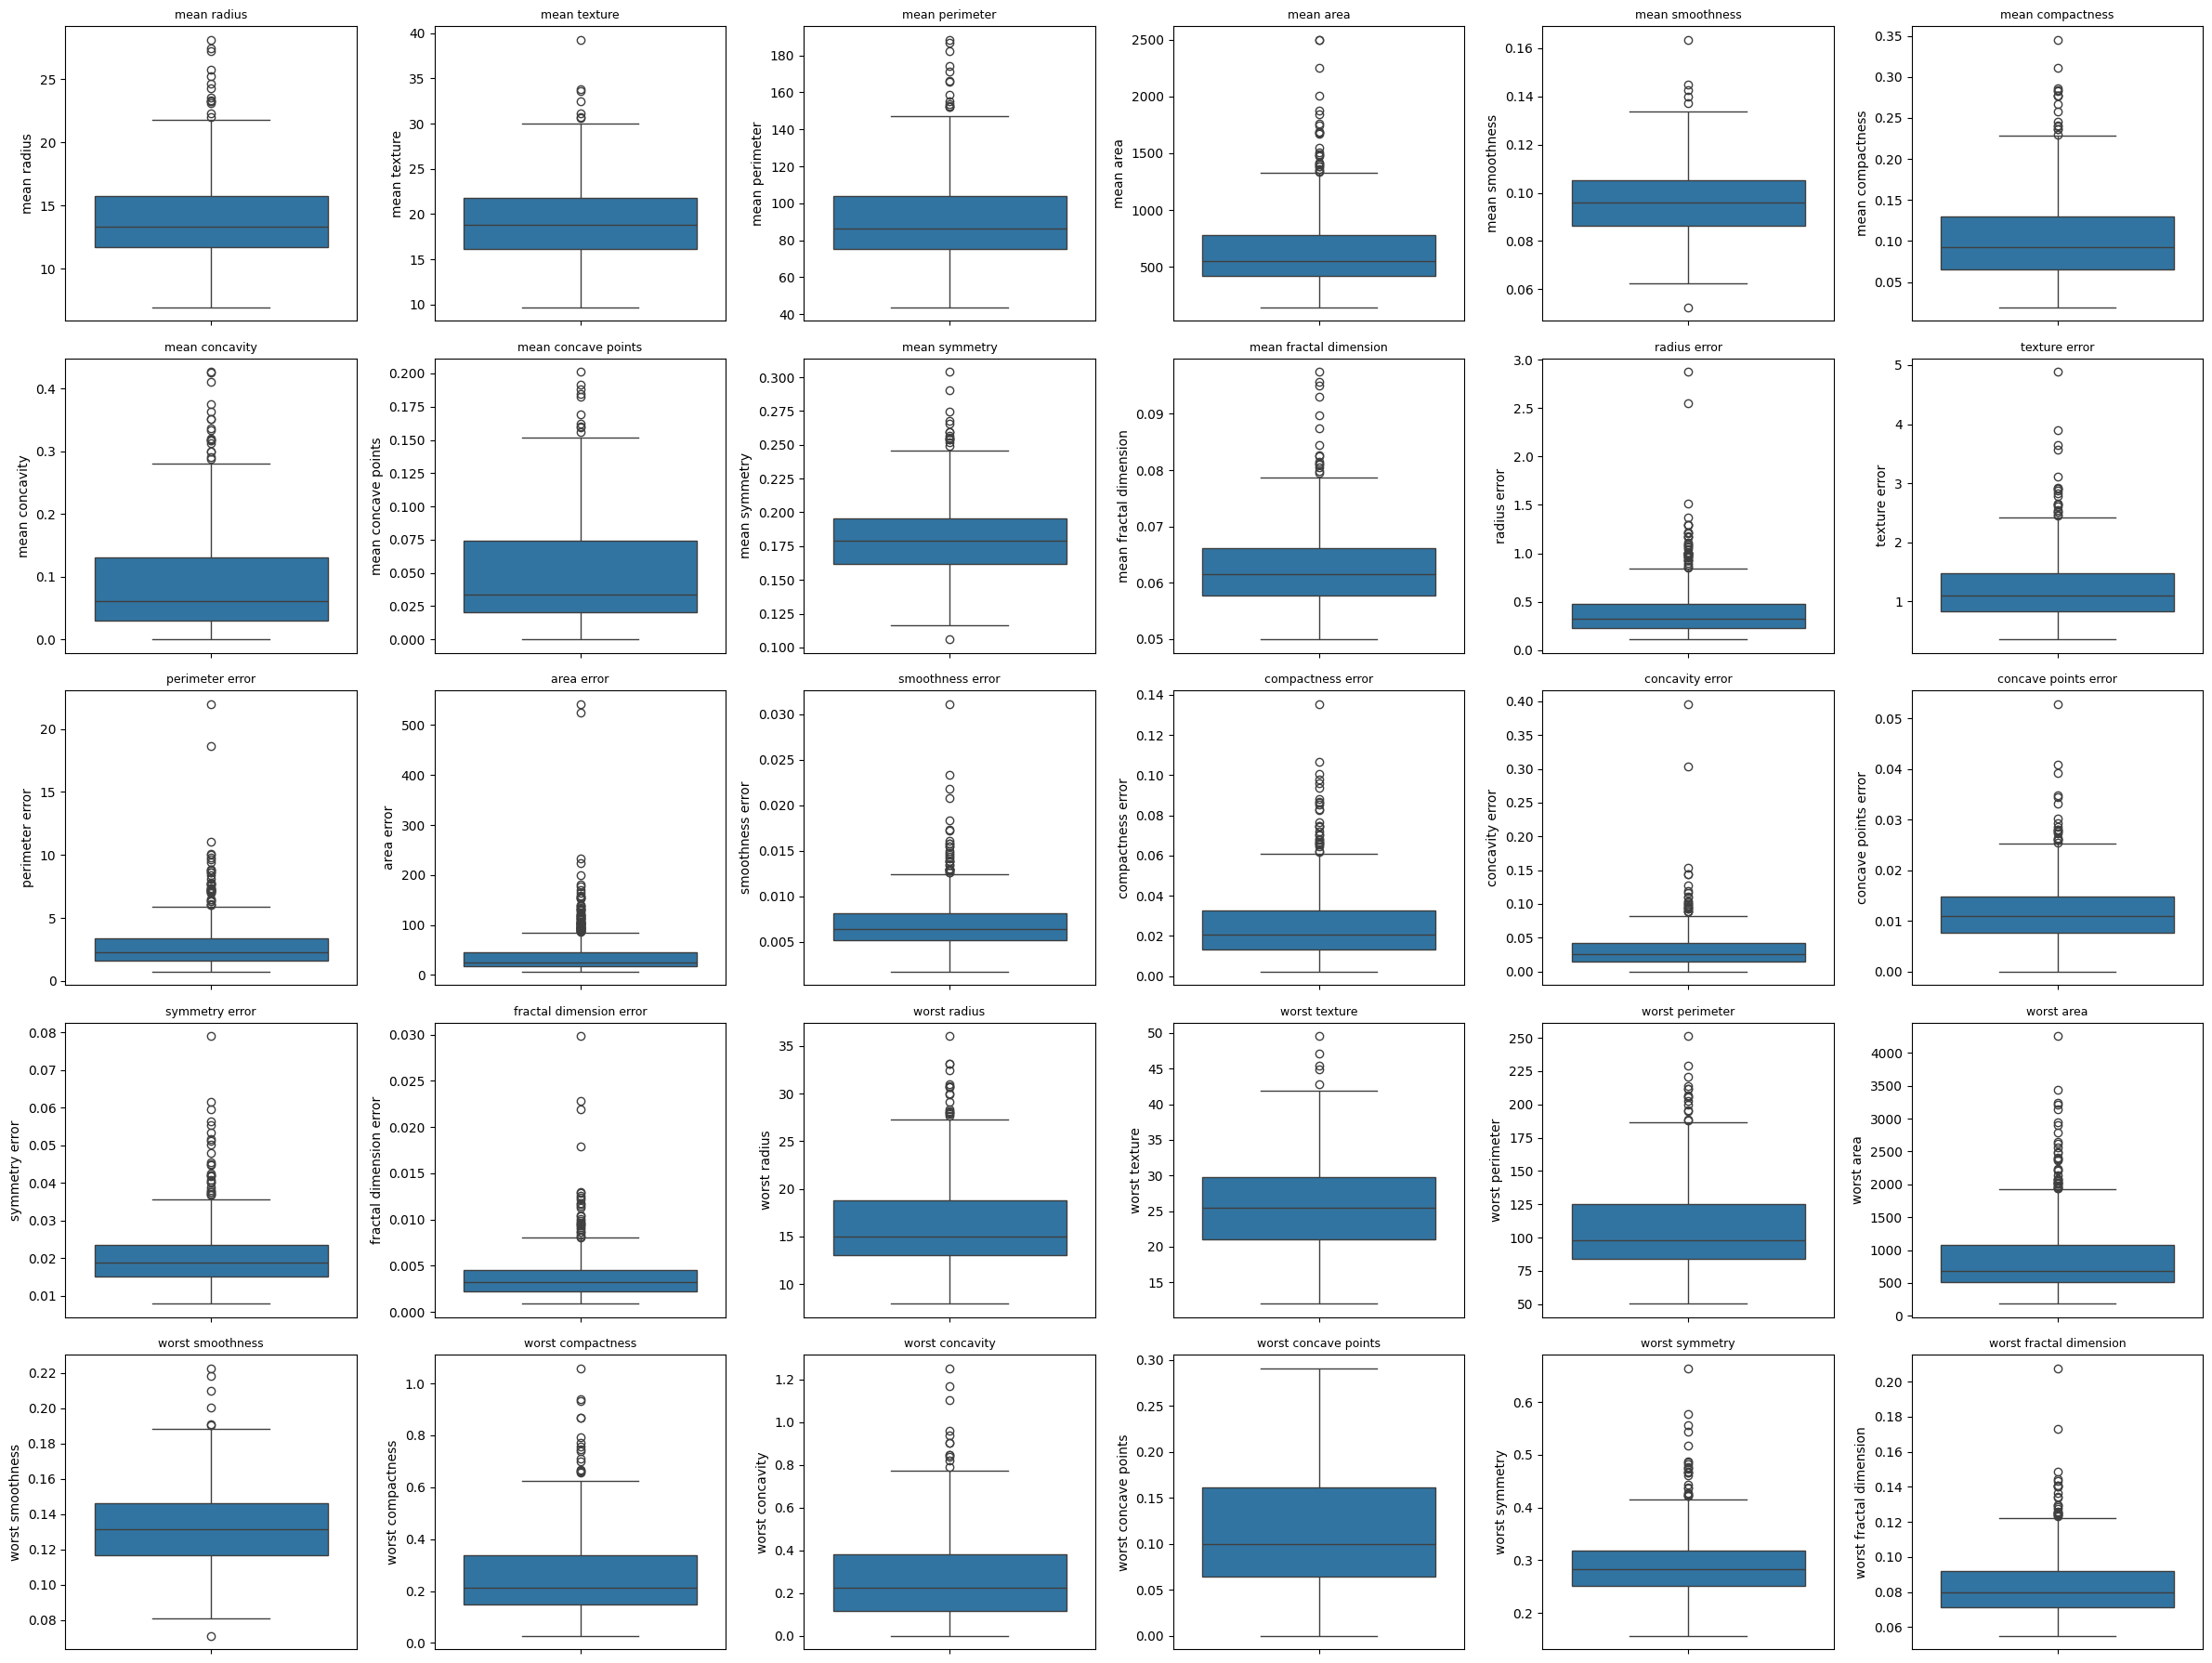

In [16]:
## Draw a boxplot for each feature
plt.figure(figsize=(24, 18))

for i, col in enumerate(X.columns):
    plt.subplot(5, 6, i + 1)
    sns.boxplot(y=X[col])
    plt.title(col, fontsize=9)
    plt.xlabel("")

plt.tight_layout()
plt.show()

# 5. Splitting the Dataset

In [17]:
# Split the data using
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.7, random_state=1, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, train_size=1/3, random_state=1, stratify=y_temp
)

In [18]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(398, 30)
(57, 30)
(114, 30)


# 4. Data Scaling

In [19]:
## Use one of the following scalers.
# StandardScaler (recommended)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_valid_scaled = sc.transform(X_valid)
X_test_scaled = sc.transform(X_test)

# 6. Feature Selection and Dimensionality Reduction 

In [20]:
## Raw data
X_train_raw = X_train_scaled.copy()

X_valid_raw = X_valid_scaled.copy()

X_test_raw = X_test_scaled.copy()

## 6.1 PCA (Principal Component Analysis)

In [21]:
## Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

In [22]:
## Determine the number of components by selecting the components whose
## explained variance ratio is greater than the average explained variance ratio.
explained_var = pca.explained_variance_ratio_
avg_var = np.mean(explained_var)

n_components = np.sum(explained_var > avg_var)
print("Selected PCA components:", n_components)

Selected PCA components: 6


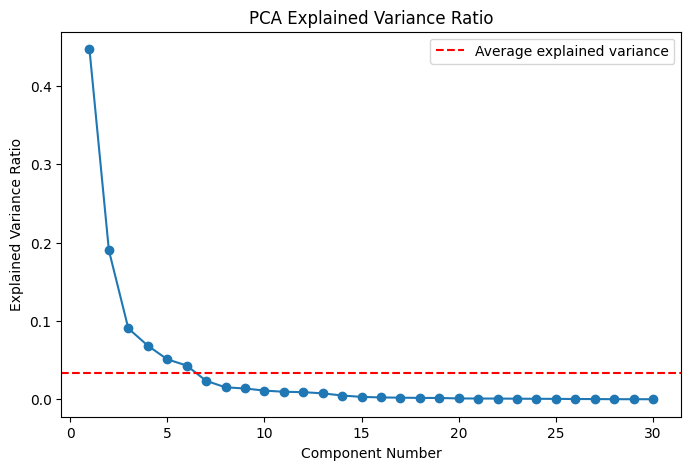

In [23]:
## Plot the explained variance graph.
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o")
plt.axhline(avg_var, color="red", linestyle="--", label="Average explained variance")
plt.title("PCA Explained Variance Ratio")
plt.xlabel("Component Number")
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.show()

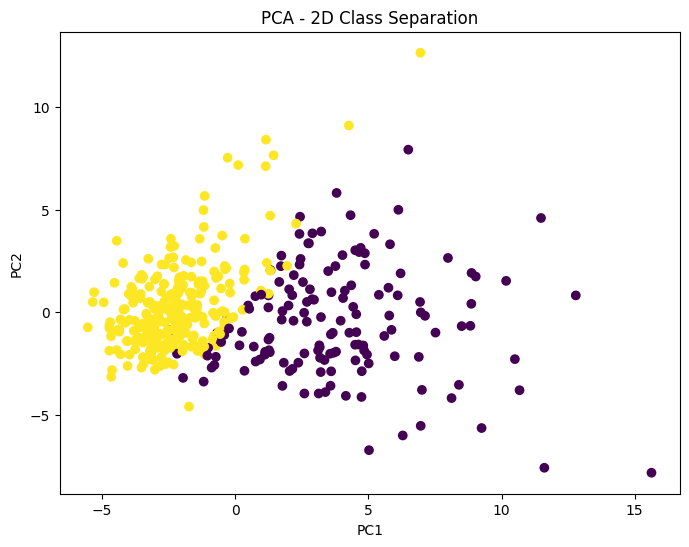

In [24]:
### Show class separation using the best two selected PCA components in a 2D scatter plot.
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="viridis")

plt.title("PCA - 2D Class Separation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [25]:
## PCA dataset
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled).copy()
X_valid_pca = pca.transform(X_valid_scaled).copy()
X_test_pca = pca.transform(X_test_scaled).copy()

## 6.2 LDA (Linear Discriminant Analysis)

In [26]:
## Apply LDA
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)

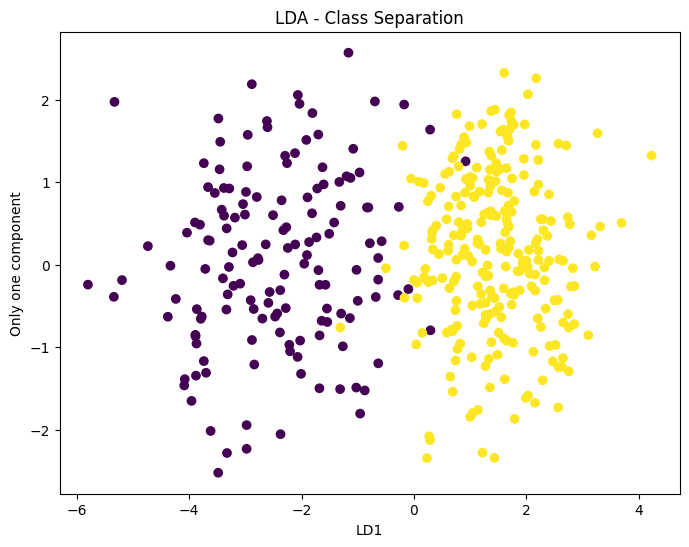

In [27]:
## Visualize class separation with the first two LDA components using a 2D scatter plot.
plt.figure(figsize=(8,6))

plt.scatter(X_train_lda[:, 0], np.random.randn(len(X_train_lda[:, 0])), c=y_train, cmap="viridis")
plt.xlabel("LD1")
plt.ylabel("Only one component")
plt.title("LDA - Class Separation")
plt.show()

In [28]:
## LDA dataset
X_valid_lda = lda.transform(X_valid_scaled).copy()
X_test_lda = lda.transform(X_test_scaled).copy()

# 7. Building the Machine Learning Models

## 7.1 Raw data

In [29]:
## The following 5 algorithms will be trained separately on each of the three data representations

# Logistic Regression
lr_raw = LogisticRegression(max_iter=1000)
lr_raw.fit(X_train_raw, y_train)

# Decision Tree
dt_raw = DecisionTreeClassifier(max_depth=5, random_state=0)
dt_raw.fit(X_train_raw, y_train)

# Random Forest
rf_raw = RandomForestClassifier(n_estimators=10, random_state=0)
rf_raw.fit(X_train_raw, y_train)

# XGBoost
xgb_raw = XGBClassifier(eval_metric="logloss", random_state=0)
xgb_raw.fit(X_train_raw, y_train)

# Naive Bayes (GaussianNB)
nb_raw = GaussianNB()
nb_raw.fit(X_train_raw, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 7.2 PCA data

In [30]:
## The following 5 algorithms will be trained separately on each of the three data representations

# Logistic Regression
lr_pca = LogisticRegression(max_iter=1000)
lr_pca.fit(X_train_pca, y_train)

# Decision Tree
dt_pca = DecisionTreeClassifier(max_depth=5, random_state=0)
dt_pca.fit(X_train_pca, y_train)

# Random Forest
rf_pca = RandomForestClassifier(n_estimators=10, random_state=0)
rf_pca.fit(X_train_pca, y_train)

# XGBoost
xgb_pca = XGBClassifier(eval_metric="logloss", random_state=0)
xgb_pca.fit(X_train_pca, y_train)

# Naive Bayes (GaussianNB)
nb_pca = GaussianNB()
nb_pca.fit(X_train_pca, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 7.3 LDA data

In [31]:
## The following 5 algorithms will be trained separately on each of the three data representations

# Logistic Regression
lr_lda = LogisticRegression(max_iter=1000)
lr_lda.fit(X_train_lda, y_train)

# Decision Tree
dt_lda = DecisionTreeClassifier(max_depth=5, random_state=0)
dt_lda.fit(X_train_lda, y_train)

# Random Forest
rf_lda = RandomForestClassifier(n_estimators=10, random_state=0)
rf_lda.fit(X_train_lda, y_train)

# XGBoost
xgb_lda = XGBClassifier(eval_metric="logloss", random_state=0)
xgb_lda.fit(X_train_lda, y_train)

# Naive Bayes (GaussianNB)
nb_lda = GaussianNB()
nb_lda.fit(X_train_lda, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


# 8. Measuring Validation Performance

## 8.1 Raw Dataset

In [32]:
# Logistic Regression
y_pred_raw = lr_raw.predict(X_valid_raw)
y_prob_raw = lr_raw.predict_proba(X_valid_raw)

lr_accuracy_raw = accuracy_score(y_valid, y_pred_raw)
lr_precision_raw = precision_score(y_valid, y_pred_raw, average="binary")
lr_recall_raw = recall_score(y_valid, y_pred_raw, average="binary")
lr_f1_raw = f1_score(y_valid, y_pred_raw, average="binary")
lr_roc_auc_raw = roc_auc_score(y_valid, y_prob_raw[:, 1])

print("Logistic Regression")
print(f"Accuracy  : {100*lr_accuracy_raw:.3f}")
print(f"Precision : {100*lr_precision_raw:.3f}")
print(f"Recall    : {100*lr_recall_raw:.3f}")
print(f"F1-score  : {100*lr_f1_raw:.3f}")
print(f"ROC-AUC   : {100*lr_roc_auc_raw:.3f}\n")

Logistic Regression
Accuracy  : 96.491
Precision : 94.737
Recall    : 100.000
F1-score  : 97.297
ROC-AUC   : 99.735



In [33]:
# Decision Tree
y_pred_raw = dt_raw.predict(X_valid_raw)
y_prob_raw = dt_raw.predict_proba(X_valid_raw)

dt_accuracy_raw = accuracy_score(y_valid, y_pred_raw)
dt_precision_raw = precision_score(y_valid, y_pred_raw, average="binary")
dt_recall_raw = recall_score(y_valid, y_pred_raw, average="binary")
dt_f1_raw = f1_score(y_valid, y_pred_raw, average="binary")
dt_roc_auc_raw = roc_auc_score(y_valid, y_prob_raw[:, 1])

print("Decision Tree")
print(f"Accuracy  : {100*dt_accuracy_raw:.3f}")
print(f"Precision : {100*dt_precision_raw:.3f}")
print(f"Recall    : {100*dt_recall_raw:.3f}")
print(f"F1-score  : {100*dt_f1_raw:.3f}")
print(f"ROC-AUC   : {100*dt_roc_auc_raw:.3f}\n")

Decision Tree
Accuracy  : 92.982
Precision : 94.444
Recall    : 94.444
F1-score  : 94.444
ROC-AUC   : 92.460



In [34]:
# Random Forest
y_pred_raw = rf_raw.predict(X_valid_raw)
y_prob_raw = rf_raw.predict_proba(X_valid_raw)

rf_accuracy_raw = accuracy_score(y_valid, y_pred_raw)
rf_precision_raw = precision_score(y_valid, y_pred_raw, average="binary")
rf_recall_raw = recall_score(y_valid, y_pred_raw, average="binary")
rf_f1_raw = f1_score(y_valid, y_pred_raw, average="binary")
rf_roc_auc_raw = roc_auc_score(y_valid, y_prob_raw[:, 1])

print("Random Forest")
print(f"Accuracy  : {100*rf_accuracy_raw:.3f}")
print(f"Precision : {100*rf_precision_raw:.3f}")
print(f"Recall    : {100*rf_recall_raw:.3f}")
print(f"F1-score  : {100*rf_f1_raw:.3f}")
print(f"ROC-AUC   : {100*rf_roc_auc_raw:.3f}\n")

Random Forest
Accuracy  : 89.474
Precision : 94.118
Recall    : 88.889
F1-score  : 91.429
ROC-AUC   : 95.767



In [35]:
# XGBoost
y_pred_raw = xgb_raw.predict(X_valid_raw)
y_prob_raw = xgb_raw.predict_proba(X_valid_raw)

xgb_accuracy_raw = accuracy_score(y_valid, y_pred_raw)
xgb_precision_raw = precision_score(y_valid, y_pred_raw, average="binary")
xgb_recall_raw = recall_score(y_valid, y_pred_raw, average="binary")
xgb_f1_raw = f1_score(y_valid, y_pred_raw, average="binary")
xgb_roc_auc_raw = roc_auc_score(y_valid, y_prob_raw[:, 1])

print("XGBoost")
print(f"Accuracy  : {100*xgb_accuracy_raw:.3f}")
print(f"Precision : {100*xgb_precision_raw:.3f}")
print(f"Recall    : {100*xgb_recall_raw:.3f}")
print(f"F1-score  : {100*xgb_f1_raw:.3f}")
print(f"ROC-AUC   : {100*xgb_roc_auc_raw:.3f}\n")

XGBoost
Accuracy  : 92.982
Precision : 94.444
Recall    : 94.444
F1-score  : 94.444
ROC-AUC   : 98.545



In [36]:
# Naive Bayes
y_pred_raw = nb_raw.predict(X_valid_raw)
y_prob_raw = nb_raw.predict_proba(X_valid_raw)

nb_accuracy_raw = accuracy_score(y_valid, y_pred_raw)
nb_precision_raw = precision_score(y_valid, y_pred_raw, average="binary")
nb_recall_raw = recall_score(y_valid, y_pred_raw, average="binary")
nb_f1_raw = f1_score(y_valid, y_pred_raw, average="binary")
nb_roc_auc_raw = roc_auc_score(y_valid, y_prob_raw[:, 1])

print("Naive Bayes")
print(f"Accuracy  : {100*nb_accuracy_raw:.3f}")
print(f"Precision : {100*nb_precision_raw:.3f}")
print(f"Recall    : {100*nb_recall_raw:.3f}")
print(f"F1-score  : {100*nb_f1_raw:.3f}")
print(f"ROC-AUC   : {100*nb_roc_auc_raw:.3f}\n")

Naive Bayes
Accuracy  : 91.228
Precision : 91.892
Recall    : 94.444
F1-score  : 93.151
ROC-AUC   : 96.825



## 8.2 PCA dataset

In [37]:
# Logistic Regression
y_pred_pca = lr_pca.predict(X_valid_pca)
y_prob_pca = lr_pca.predict_proba(X_valid_pca)

lr_accuracy_pca = accuracy_score(y_valid, y_pred_pca)
lr_precision_pca = precision_score(y_valid, y_pred_pca, average="binary")
lr_recall_pca = recall_score(y_valid, y_pred_pca, average="binary")
lr_f1_pca = f1_score(y_valid, y_pred_pca, average="binary")
lr_roc_auc_pca = roc_auc_score(y_valid, y_prob_pca[:, 1])

print("Logistic Regression")
print(f"Accuracy  : {100*lr_accuracy_pca:.3f}")
print(f"Precision : {100*lr_precision_pca:.3f}")
print(f"Recall    : {100*lr_recall_pca:.3f}")
print(f"F1-score  : {100*lr_f1_pca:.3f}")
print(f"ROC-AUC   : {100*lr_roc_auc_pca:.3f}\n")

Logistic Regression
Accuracy  : 94.737
Precision : 94.595
Recall    : 97.222
F1-score  : 95.890
ROC-AUC   : 99.206



In [38]:
# Decision Tree
y_pred_pca = dt_pca.predict(X_valid_pca)
y_prob_pca = dt_pca.predict_proba(X_valid_pca)

dt_accuracy_pca = accuracy_score(y_valid, y_pred_pca)
dt_precision_pca = precision_score(y_valid, y_pred_pca, average="binary")
dt_recall_pca = recall_score(y_valid, y_pred_pca, average="binary")
dt_f1_pca = f1_score(y_valid, y_pred_pca, average="binary")
dt_roc_auc_pca = roc_auc_score(y_valid, y_prob_pca[:, 1])

print("Decision Tree")
print(f"Accuracy  : {100*dt_accuracy_pca:.3f}")
print(f"Precision : {100*dt_precision_pca:.3f}")
print(f"Recall    : {100*dt_recall_pca:.3f}")
print(f"F1-score  : {100*dt_f1_pca:.3f}")
print(f"ROC-AUC   : {100*dt_roc_auc_pca:.3f}\n")

Decision Tree
Accuracy  : 85.965
Precision : 91.176
Recall    : 86.111
F1-score  : 88.571
ROC-AUC   : 87.103



In [39]:
# Random Forest
y_pred_pca = rf_pca.predict(X_valid_pca)
y_prob_pca = rf_pca.predict_proba(X_valid_pca)

rf_accuracy_pca = accuracy_score(y_valid, y_pred_pca)
rf_precision_pca = precision_score(y_valid, y_pred_pca, average="binary")
rf_recall_pca = recall_score(y_valid, y_pred_pca, average="binary")
rf_f1_pca = f1_score(y_valid, y_pred_pca, average="binary")
rf_roc_auc_pca = roc_auc_score(y_valid, y_prob_pca[:, 1])

print("Random Forest")
print(f"Accuracy  : {100*rf_accuracy_pca:.3f}")
print(f"Precision : {100*rf_precision_pca:.3f}")
print(f"Recall    : {100*rf_recall_pca:.3f}")
print(f"F1-score  : {100*rf_f1_pca:.3f}")
print(f"ROC-AUC   : {100*rf_roc_auc_pca:.3f}\n")

Random Forest
Accuracy  : 89.474
Precision : 91.667
Recall    : 91.667
F1-score  : 91.667
ROC-AUC   : 97.024



In [40]:
# XGBoost
y_pred_pca = xgb_pca.predict(X_valid_pca)
y_prob_pca = xgb_pca.predict_proba(X_valid_pca)

xgb_accuracy_pca = accuracy_score(y_valid, y_pred_pca)
xgb_precision_pca = precision_score(y_valid, y_pred_pca, average="binary")
xgb_recall_pca = recall_score(y_valid, y_pred_pca, average="binary")
xgb_f1_pca = f1_score(y_valid, y_pred_pca, average="binary")
xgb_roc_auc_pca = roc_auc_score(y_valid, y_prob_pca[:, 1])

print("XGBoost")
print(f"Accuracy  : {100*xgb_accuracy_pca:.3f}")
print(f"Precision : {100*xgb_precision_pca:.3f}")
print(f"Recall    : {100*xgb_recall_pca:.3f}")
print(f"F1-score  : {100*xgb_f1_pca:.3f}")
print(f"ROC-AUC   : {100*xgb_roc_auc_pca:.3f}\n")

XGBoost
Accuracy  : 91.228
Precision : 91.892
Recall    : 94.444
F1-score  : 93.151
ROC-AUC   : 97.487



In [41]:
# Naive Bayes
y_pred_pca = nb_pca.predict(X_valid_pca)
y_prob_pca = nb_pca.predict_proba(X_valid_pca)

nb_accuracy_pca = accuracy_score(y_valid, y_pred_pca)
nb_precision_pca = precision_score(y_valid, y_pred_pca, average="binary")
nb_recall_pca = recall_score(y_valid, y_pred_pca, average="binary")
nb_f1_pca = f1_score(y_valid, y_pred_pca, average="binary")
nb_roc_auc_pca = roc_auc_score(y_valid, y_prob_pca[:, 1])

print("Naive Bayes")
print(f"Accuracy  : {100*nb_accuracy_pca:.3f}")
print(f"Precision : {100*nb_precision_pca:.3f}")
print(f"Recall    : {100*nb_recall_pca:.3f}")
print(f"F1-score  : {100*nb_f1_pca:.3f}")
print(f"ROC-AUC   : {100*nb_roc_auc_pca:.3f}\n")

Naive Bayes
Accuracy  : 91.228
Precision : 89.744
Recall    : 97.222
F1-score  : 93.333
ROC-AUC   : 97.751



## 8.3 LDA dataset

In [42]:
# Logistic Regression
y_pred_lda = lr_lda.predict(X_valid_lda)
y_prob_lda = lr_lda.predict_proba(X_valid_lda)

lr_accuracy_lda = accuracy_score(y_valid, y_pred_lda)
lr_precision_lda = precision_score(y_valid, y_pred_lda, average="binary")
lr_recall_lda = recall_score(y_valid, y_pred_lda, average="binary")
lr_f1_lda = f1_score(y_valid, y_pred_lda, average="binary")
lr_roc_auc_lda = roc_auc_score(y_valid, y_prob_lda[:, 1])

print("Logistic Regression")
print(f"Accuracy  : {100*lr_accuracy_lda:.3f}")
print(f"Precision : {100*lr_precision_lda:.3f}")
print(f"Recall    : {100*lr_recall_lda:.3f}")
print(f"F1-score  : {100*lr_f1_lda:.3f}")
print(f"ROC-AUC   : {100*lr_roc_auc_lda:.3f}\n")

Logistic Regression
Accuracy  : 94.737
Precision : 97.143
Recall    : 94.444
F1-score  : 95.775
ROC-AUC   : 99.339



In [43]:
# Decision Tree
y_pred_lda = dt_lda.predict(X_valid_lda)
y_prob_lda = dt_lda.predict_proba(X_valid_lda)

dt_accuracy_lda = accuracy_score(y_valid, y_pred_lda)
dt_precision_lda = precision_score(y_valid, y_pred_lda, average="binary")
dt_recall_lda = recall_score(y_valid, y_pred_lda, average="binary")
dt_f1_lda = f1_score(y_valid, y_pred_lda, average="binary")
dt_roc_auc_lda = roc_auc_score(y_valid, y_prob_lda[:, 1])

print("Decision Tree")
print(f"Accuracy  : {100*dt_accuracy_lda:.3f}")
print(f"Precision : {100*dt_precision_lda:.3f}")
print(f"Recall    : {100*dt_recall_lda:.3f}")
print(f"F1-score  : {100*dt_f1_lda:.3f}")
print(f"ROC-AUC   : {100*dt_roc_auc_lda:.3f}\n")

Decision Tree
Accuracy  : 92.982
Precision : 94.444
Recall    : 94.444
F1-score  : 94.444
ROC-AUC   : 92.460



In [44]:
# Random Forest
y_pred_lda = rf_lda.predict(X_valid_lda)
y_prob_lda = rf_lda.predict_proba(X_valid_lda)

rf_accuracy_lda = accuracy_score(y_valid, y_pred_lda)
rf_precision_lda = precision_score(y_valid, y_pred_lda, average="binary")
rf_recall_lda = recall_score(y_valid, y_pred_lda, average="binary")
rf_f1_lda = f1_score(y_valid, y_pred_lda, average="binary")
rf_roc_auc_lda = roc_auc_score(y_valid, y_prob_lda[:, 1])

print("Random Forest")
print(f"Accuracy  : {100*rf_accuracy_lda:.3f}")
print(f"Precision : {100*rf_precision_lda:.3f}")
print(f"Recall    : {100*rf_recall_lda:.3f}")
print(f"F1-score  : {100*rf_f1_lda:.3f}")
print(f"ROC-AUC   : {100*rf_roc_auc_lda:.3f}\n")

Random Forest
Accuracy  : 92.982
Precision : 94.444
Recall    : 94.444
F1-score  : 94.444
ROC-AUC   : 97.024



In [45]:
# XGBoost
y_pred_lda = xgb_lda.predict(X_valid_lda)
y_prob_lda = xgb_lda.predict_proba(X_valid_lda)

xgb_accuracy_lda = accuracy_score(y_valid, y_pred_lda)
xgb_precision_lda = precision_score(y_valid, y_pred_lda, average="binary")
xgb_recall_lda = recall_score(y_valid, y_pred_lda, average="binary")
xgb_f1_lda = f1_score(y_valid, y_pred_lda, average="binary")
xgb_roc_auc_lda = roc_auc_score(y_valid, y_prob_lda[:, 1])

print("XGBoost")
print(f"Accuracy  : {100*xgb_accuracy_lda:.3f}")
print(f"Precision : {100*xgb_precision_lda:.3f}")
print(f"Recall    : {100*xgb_recall_lda:.3f}")
print(f"F1-score  : {100*xgb_f1_lda:.3f}")
print(f"ROC-AUC   : {100*xgb_roc_auc_lda:.3f}\n")

XGBoost
Accuracy  : 92.982
Precision : 97.059
Recall    : 91.667
F1-score  : 94.286
ROC-AUC   : 99.074



In [46]:
# Naive Bayes
y_pred_lda = nb_lda.predict(X_valid_lda)
y_prob_lda = nb_lda.predict_proba(X_valid_lda)

nb_accuracy_lda = accuracy_score(y_valid, y_pred_lda)
nb_precision_lda = precision_score(y_valid, y_pred_lda, average="binary")
nb_recall_lda = recall_score(y_valid, y_pred_lda, average="binary")
nb_f1_lda = f1_score(y_valid, y_pred_lda, average="binary")
nb_roc_auc_lda = roc_auc_score(y_valid, y_prob_lda[:, 1])

print("Naive Bayes")
print(f"Accuracy  : {100*nb_accuracy_lda:.3f}")
print(f"Precision : {100*nb_precision_lda:.3f}")
print(f"Recall    : {100*nb_recall_lda:.3f}")
print(f"F1-score  : {100*nb_f1_lda:.3f}")
print(f"ROC-AUC   : {100*nb_roc_auc_lda:.3f}\n")

Naive Bayes
Accuracy  : 94.737
Precision : 94.595
Recall    : 97.222
F1-score  : 95.890
ROC-AUC   : 99.339



In [47]:
comparison_table = pd.DataFrame([
    ["Logistic Regression", "Raw", lr_accuracy_raw, lr_precision_raw, lr_recall_raw, lr_f1_raw, lr_roc_auc_raw],
    ["Decision Tree", "Raw", dt_accuracy_raw, dt_precision_raw, dt_recall_raw, dt_f1_raw, dt_roc_auc_raw],
    ["Random Forest", "Raw", rf_accuracy_raw, rf_precision_raw, rf_recall_raw, rf_f1_raw, rf_roc_auc_raw],
    ["XGBoost", "Raw", xgb_accuracy_raw, xgb_precision_raw, xgb_recall_raw, xgb_f1_raw, xgb_roc_auc_raw],
    ["GaussianNB", "Raw", nb_accuracy_raw, nb_precision_raw, nb_recall_raw, nb_f1_raw, nb_roc_auc_raw],

    ["Logistic Regression", "PCA", lr_accuracy_pca, lr_precision_pca, lr_recall_pca, lr_f1_pca, lr_roc_auc_pca],
    ["Decision Tree", "PCA", dt_accuracy_pca, dt_precision_pca, dt_recall_pca, dt_f1_pca, dt_roc_auc_pca],
    ["Random Forest", "PCA", rf_accuracy_pca, rf_precision_pca, rf_recall_pca, rf_f1_pca, rf_roc_auc_pca],
    ["XGBoost", "PCA", xgb_accuracy_pca, xgb_precision_pca, xgb_recall_pca, xgb_f1_pca, xgb_roc_auc_pca],
    ["GaussianNB", "PCA", nb_accuracy_pca, nb_precision_pca, nb_recall_pca, nb_f1_pca, nb_roc_auc_pca],

    ["Logistic Regression", "LDA", lr_accuracy_lda, lr_precision_lda, lr_recall_lda, lr_f1_lda, lr_roc_auc_lda],
    ["Decision Tree", "LDA", dt_accuracy_lda, dt_precision_lda, dt_recall_lda, dt_f1_lda, dt_roc_auc_lda],
    ["Random Forest", "LDA", rf_accuracy_lda, rf_precision_lda, rf_recall_lda, rf_f1_lda, rf_roc_auc_lda],
    ["XGBoost", "LDA", xgb_accuracy_lda, xgb_precision_lda, xgb_recall_lda, xgb_f1_lda, xgb_roc_auc_lda],
    ["GaussianNB", "LDA", nb_accuracy_lda, nb_precision_lda, nb_recall_lda, nb_f1_lda, nb_roc_auc_lda]
], columns=["Model", "Representation", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"])

comparison_table = comparison_table.sort_values(by=["Recall"], ascending=False).reset_index(drop=True)

print(comparison_table.round(4))

                  Model Representation  Accuracy  Precision  Recall  F1-score  \
0   Logistic Regression            Raw    0.9649     0.9474  1.0000    0.9730   
1   Logistic Regression            PCA    0.9474     0.9459  0.9722    0.9589   
2            GaussianNB            PCA    0.9123     0.8974  0.9722    0.9333   
3            GaussianNB            LDA    0.9474     0.9459  0.9722    0.9589   
4         Decision Tree            Raw    0.9298     0.9444  0.9444    0.9444   
5               XGBoost            Raw    0.9298     0.9444  0.9444    0.9444   
6            GaussianNB            Raw    0.9123     0.9189  0.9444    0.9315   
7               XGBoost            PCA    0.9123     0.9189  0.9444    0.9315   
8   Logistic Regression            LDA    0.9474     0.9714  0.9444    0.9577   
9         Decision Tree            LDA    0.9298     0.9444  0.9444    0.9444   
10        Random Forest            LDA    0.9298     0.9444  0.9444    0.9444   
11        Random Forest     

# 9. Evaluating the Best Model on the Test Set

## 9.1 Performance Metrics

In [48]:
y_pred = lr_raw.predict(X_test_raw)
y_prob = lr_raw.predict_proba(X_test_raw)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="binary")
test_recall = recall_score(y_test, y_pred, average="binary")
test_f1 = f1_score(y_test, y_pred, average="binary")
test_roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print("Logistic Regression - Raw")
print(f"Accuracy  : {100*test_accuracy:.3f}")
print(f"Precision : {100*test_precision:.3f}")
print(f"Recall    : {100*test_recall:.3f}")
print(f"F1-score  : {100*test_f1:.3f}")
print(f"ROC-AUC   : {100*test_roc_auc:.3f}\n")

Logistic Regression - Raw
Accuracy  : 95.614
Precision : 95.833
Recall    : 97.183
F1-score  : 96.503
ROC-AUC   : 99.378



## 9.2 Confusion Matrix

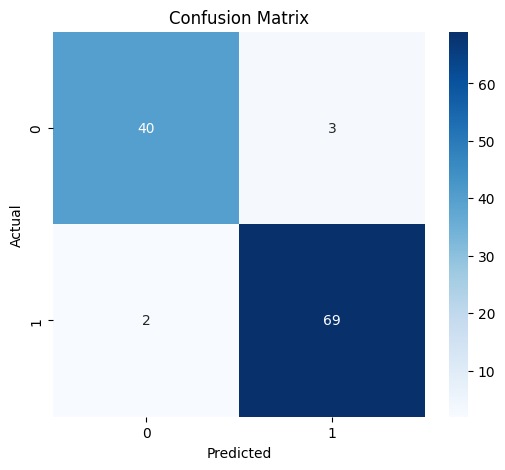

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9.3 ROC Curve

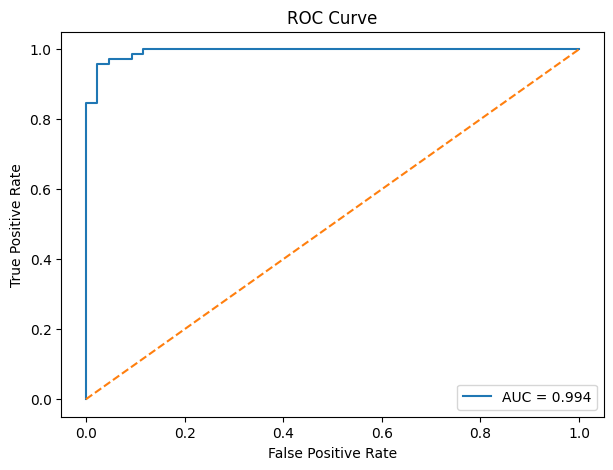

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
auc_value = roc_auc_score(y_test, y_prob[:, 1])

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], "--")
plt.title(f"ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 10. XAI - SHAP Explainability Analysis

## 10.1 SHAP Analysis for the best validation Model

In [51]:
X_train_raw_df = pd.DataFrame(X_train_raw, columns=cancer_data["feature_names"])
X_valid_raw_df = pd.DataFrame(X_valid_raw, columns=cancer_data["feature_names"])

explainer_raw = shap.LinearExplainer(lr_raw, X_train_raw_df)
shap_values_raw = explainer_raw.shap_values(X_valid_raw_df)

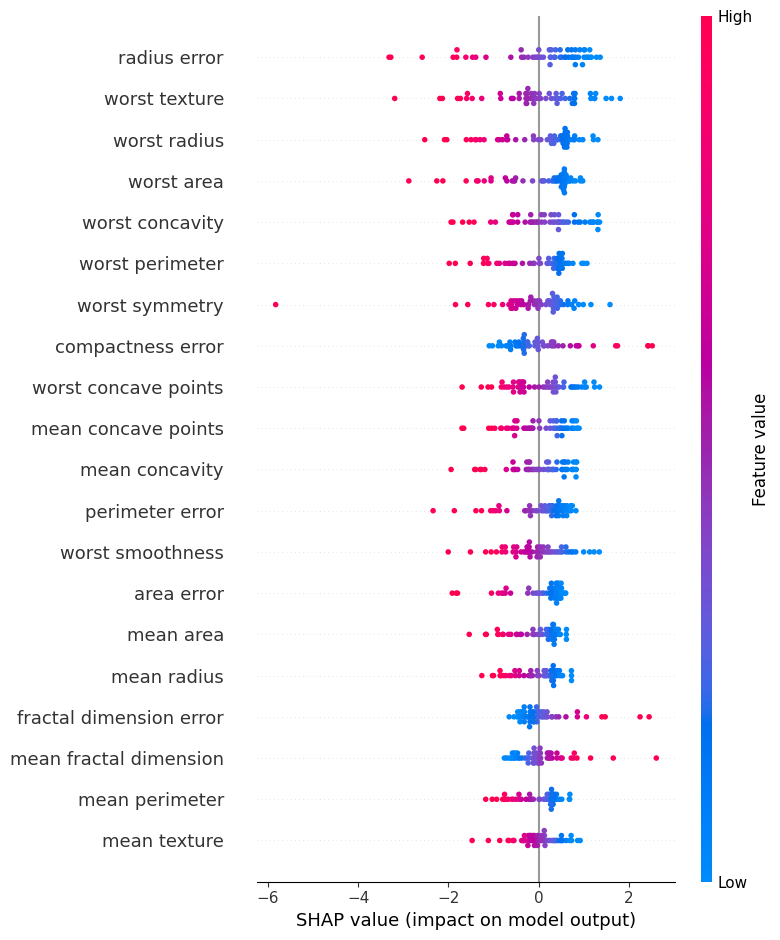

In [52]:
shap.summary_plot(shap_values_raw, X_valid_raw_df)

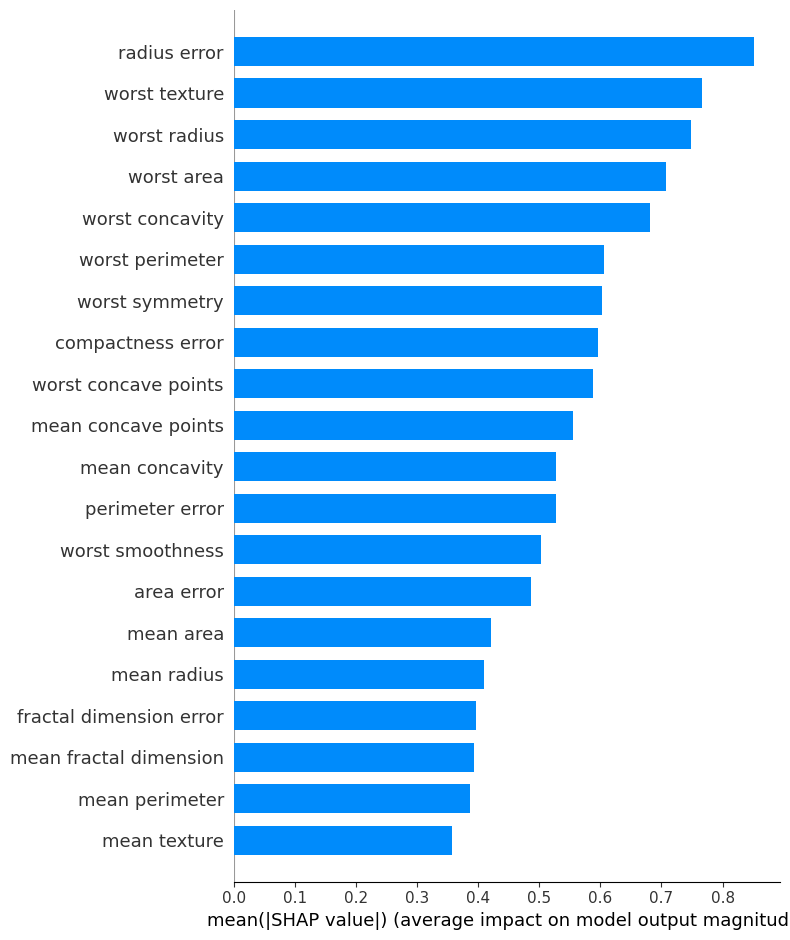

In [53]:
shap.summary_plot(shap_values_raw, X_valid_raw_df, plot_type="bar")

## 10.2 SHAP Comparison for PCA and LDA Representation

In [54]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])])
X_valid_pca_df = pd.DataFrame(X_valid_pca, columns=[f"PC{i+1}" for i in range(X_valid_pca.shape[1])])

explainer_pca = shap.LinearExplainer(lr_pca, X_train_pca_df)
shap_values_pca = explainer_pca.shap_values(X_valid_pca_df)

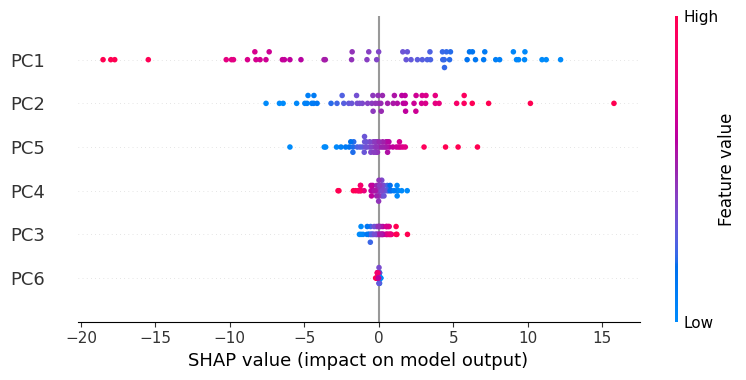

In [55]:
shap.summary_plot(shap_values_pca, X_valid_pca_df)

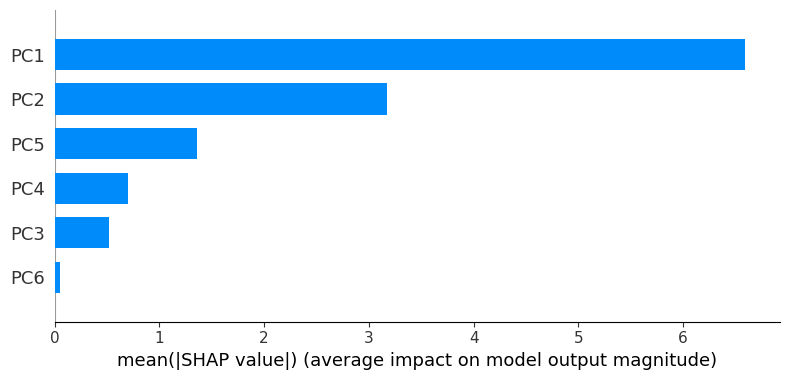

In [56]:
shap.summary_plot(shap_values_pca, X_valid_pca_df, plot_type="bar")

In [57]:
X_train_lda_df = pd.DataFrame(X_train_lda, columns=[f"LDA{i+1}" for i in range(X_train_lda.shape[1])])
X_valid_lda_df = pd.DataFrame(X_valid_lda, columns=[f"LDA{i+1}" for i in range(X_valid_lda.shape[1])])

explainer_lda = shap.LinearExplainer(lr_lda, X_train_lda_df)
shap_values_lda = explainer_lda.shap_values(X_valid_lda_df)

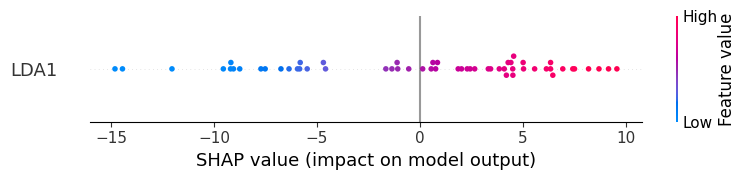

In [58]:
shap.summary_plot(shap_values_lda, X_valid_lda_df)

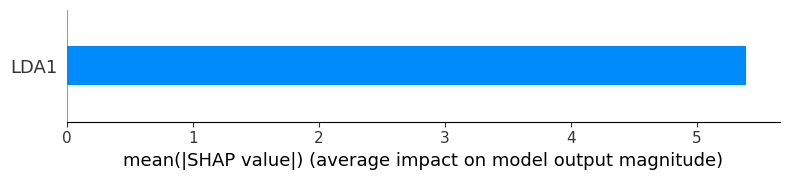

In [59]:
shap.summary_plot(shap_values_lda, X_valid_lda_df, plot_type="bar")